# Regression Analysis

The focus on this page is to analyze the linear regression problem in a more rigourous manor from a statistical perspective.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.linalg as scla
import matplotlib.pyplot as plt



## For R-like Regression Analysis
import statsmodels.api as sm

In [21]:
# Useful function for coordinate descent for Lasso
def S_func(z, alpha):
    s = np.sign(z)*np.max([0.0, np.abs(z) - alpha])
    return s

In [22]:
## Writing my own least squares model ##
def llsq(A, y, alpha = None, alphas = None, Reg = None, CV = False, max_iter = 10000):
    ## Inputs ##
    # A: Data Matix, y: Output/P.O.I, alpha/(s): regularization constant/(s)
    # Reg: Regularization method, CV: Cross validation
    ############

    # Basic shape check
    if A.shape[0] != y.shape[0]:
        raise ValueError(
            f"A and y must have same number of rows (samples); "
            f"got A.shape[0]={A.shape[0]}, y.shape[0]={y.shape[0]}"
        )

    # Check Reg argument
    valid_regs = {None, "Ridge", "Lasso"}
    if Reg not in valid_regs:
        raise ValueError(f"Reg must be one of {valid_regs}, got {Reg!r}")

    # If using CV, alphas must be provided and non-empty
    if CV:
        if alphas is None:
            raise ValueError("CV=True requires `alphas` to be provided.")
        alphas = np.atleast_1d(alphas)
        if alphas.size == 0:
            raise ValueError("`alphas` must be a non-empty 1D array.")

    # If using regularization without CV, alpha must be provided
    if (Reg is not None) and (not CV) and (alpha is None):
        raise ValueError(
            "Regularization is requested (Reg != None) but `alpha` is None "
            "and CV=False. Provide `alpha` or set CV=True with `alphas`."
        )
    
    n_s = A.shape[0]
    n_var = A.shape[1]

    if CV == True:
        n_splits = 5
        kf = KFold(n_splits, shuffle=True, random_state=42)

        i = -1
        score = np.zeros((n_splits, alphas.shape[0]))
        for fold, (train_idx, test_idx) in enumerate(kf.split(A)):
            i += 1
            j = -1
            for a in alphas:
                j += 1
                A_train, A_test = A[train_idx], A[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]
                c_p = llsq(A_train, y_train, alpha = a, Reg = Reg)
                y_test_p = A_test @ c_p
                score[i, j] = r2_score(y_test, y_test_p)
        score = np.mean(score, axis=0)
        alpha = alphas[np.argmax(score)]
        
    
    # Reduced SVD: A = U @ S @ V.T
    U, S, Vh = scla.svd(A, full_matrices = False)
    
    # No Regularization
    if Reg == None:

        # A+ = V @ S^(-1) @ U.T
        x = Vh.T @ np.diag(S**(-1)) @ U.T @ y
    
    # Ridge Regularization
    elif Reg == "Ridge":
        S_pseudo = (S**(2) + alpha)**(-1)*S
        x = Vh.T @ np.diag(S_pseudo) @ U.T @ y

    elif Reg == "Lasso":
        y = y.ravel()
        x = np.zeros(n_var)
        col_norm2 = np.sum(A**2, axis=0)
        for w in range(max_iter):
            x_old = x.copy()
            for k in range(n_var):
                r_k = y - A @ x + A[:, k] * x[k]
                rho_k = A[:, k].dot(r_k)
                x[k] = S_func(rho_k, alpha)/col_norm2[k]
            
            if np.linalg.norm(x - x_old, ord=2) < 1e-7:
                break

    if CV == False:
        return x
    else:
        return x, alpha

## Toy Problem

After too much thought, I decided to generate a test problem for estimating linear parameters. We want no priors on $\alpha$ or $\beta$.

$$
\begin{aligned}
y_i &\sim \text{Normal}(\mu_i, \sigma) \\
\mu_i &= \alpha + \beta x_i \\
\alpha &\propto 1 \\
\beta &\propto 1 \\
\sigma &\sim \text{Uniform}(0,20) \\
\end{aligned}
$$

Let us see what our model problem looks like.

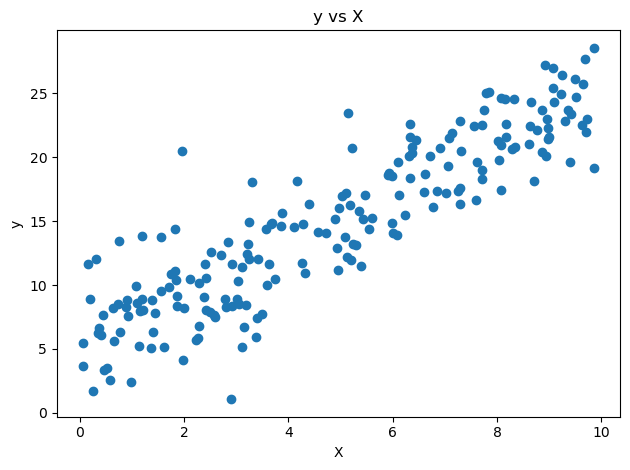

In [29]:
np.random.seed(42)

n = 200

# True parameters
alpha_true = 5.0     # intercept
beta_true  = 2.0     # slope
sigma      = 3.0     # noise std

# Predictor
X = np.random.uniform(0, 10, size=n)

# Response: y = alpha + beta * X + noise
noise = np.random.normal(0, sigma, size=n)
y = alpha_true + beta_true * X + noise

plt.scatter(X, y)
plt.xlabel("X")          # x-axis label
plt.ylabel("y")          # y-axis label
plt.title("y vs X")      # plot title
plt.tight_layout()
plt.show()

## Classical OLS without priors

We will express the minimization problem in the minimum residual form. Let us say we collect measurements $\hat{y}$, where measurements have a linear relationship with some state variables $x$. We describe the relationship as

$$ 
\hat{y} = H x + v,
$$

where $v$ is noise, with mean zero and distributed normally. We can express our estimate for $x$, $\hat{x}$, as

$$
\hat{x} = M\hat{y} + n
$$

We want to minimize the function

$$
J_i = \frac{1}{2} \text{E}[(\hat{x}_i - x_i)^2]
$$

to minimize variance. Say we have perfect estimates $y$. Then we have ${y} = H x$, or $v = 0$.  Then we have $x = MHx + n$. We can impose seemingly natural constraints

$$
\begin{aligned}
n &= 0 \\
MH &= I \\
H^T M^T &= I \\
\end{aligned}
$$

so that 

$$
\hat{x} = M\hat{y}.
$$

If we solve the minimization problem for $J_i$, we eventually arrive at 

$$
M = (H^T R^{-1} H)^{-1} H^T R^{-1},
$$

where $R = \text{cov}({v})$. If all measurements have equal covariance (and in our case we only have one measurement), we arrive at the traditional least squares format

$$
M = (H^T H)^{-1} H^T,
$$

As a note, I am standardizing and centering data.

1.9765786795475075


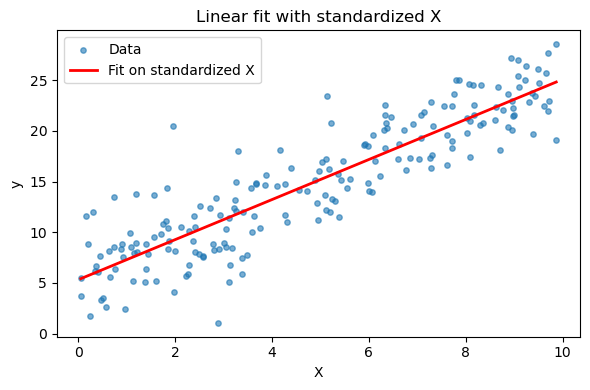

beta (standardized X) = 5.814170992955552


In [50]:
X_mean = np.mean(X)
X_std = np.std(X)
X_stand_cent = ((X - X_mean)/X_std).reshape(-1, 1)

y_mean = np.mean(y)


beta = llsq(X_stand_cent, y - y_mean)[0]
print(beta/X_std)

                 # ensure scalar

# Scatter of original data
plt.figure(figsize=(6, 4))
plt.scatter(X, y, s=15, alpha=0.6, label="Data")

# Regression line in original X units
x_line = np.linspace(X.min(), X.max(), 100)
x_line_std = (x_line - X_mean) / X_std
y_line = beta * x_line_std  +  y_mean      # since model is y = beta * X_std (no intercept)

plt.plot(x_line, y_line, color="red", linewidth=2, label="Fit on standardized X")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear fit with standardized X")
plt.legend()
plt.tight_layout()
plt.show()

print("beta (standardized X) =", beta)

